# 07 — Temporal Analysis: Full Window (15 timepoints)

This notebook restarts the temporal analysis from scratch using only the shared preprocessed phasor outputs in `/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor`.

Goal for the first pass:
- verify which files contain real temporal information
- inspect available timepoints per file
- build simple per-file temporal summaries directly from the saved cell arrays and metadata
- avoid relying on earlier helper scripts until we understand every step

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path('/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor')
DYE_LIST = ['LipiBlue', '342', 'BODIPY', 'pHrodo', 'TMRM', 'Lyso', 'Tubulin']

FILE_INFO = [
    ('CNTL-MB231', 'Control'),
    ('TAMO-MB231', 'Chemoresistant'),
    ('CNTL', 'Control'),
    ('CNTL_2', 'Control'),
    ('CNTL_75uM_p1', 'Control'),
    ('CNTL_75uM_p2', 'Control'),
    ('CNTL_75uM_p3', 'Control'),
    ('CNTL_75uM_p4', 'Control'),
    ('TAMO_p1', 'Chemoresistant'),
    ('TAMO_p2', 'Chemoresistant'),
]

print(f'Data dir exists: {DATA_DIR.exists()}')
print(f'Number of expected files: {len(FILE_INFO)}')

Data dir exists: True
Number of expected files: 10


## 1. Inspect metadata and timepoint coverage

Before computing anything, we verify what the saved metadata says about timepoints, tile counts, and group labels.

In [12]:
records = []
meta_by_file = {}

for file_name, group in FILE_INFO:
    meta_path = DATA_DIR / f'{file_name}_cells_meta.csv'
    arr_path = DATA_DIR / f'{file_name}_cells.npy'
    meta = pd.read_csv(meta_path)
    meta_by_file[file_name] = meta

    records.append({
        'file': file_name,
        'group': group,
        'n_cells': len(meta),
        'n_tiles': meta['tile'].nunique(),
        'n_timepoints': meta['time'].nunique(),
        'min_time': int(meta['time'].min()),
        'max_time': int(meta['time'].max()),
        'array_exists': arr_path.exists(),
        'meta_group_values': ', '.join(sorted(meta['group'].astype(str).unique())),
    })

df_files = pd.DataFrame(records).sort_values(['group', 'file']).reset_index(drop=True)
display(df_files)

,file,group,n_cells,n_tiles,n_timepoints,min_time,max_time,array_exists,meta_group_values
0,TAMO-MB231,Chemoresistant,5750,25,15,0,14,True,Chemoresistant
1,TAMO_p1,Chemoresistant,11900,25,24,0,23,True,Chemoresistant
2,TAMO_p2,Chemoresistant,9725,25,24,0,23,True,Chemoresistant
3,CNTL,Control,493,9,1,0,0,True,Control
4,CNTL-MB231,Control,4500,25,15,0,14,True,Control
5,CNTL_2,Control,253,9,1,0,0,True,Control
6,CNTL_75uM_p1,Control,6012,9,24,0,23,True,Control
7,CNTL_75uM_p2,Control,3231,9,24,0,23,True,Control
8,CNTL_75uM_p3,Control,4131,9,24,0,23,True,Control
9,CNTL_75uM_p4,Control,1692,9,24,0,23,True,Control


In [13]:
# Check for cached temporal summary
CACHE_DIR = Path('/baldig/bioprojects2/emartinl/chemores/cache_temporal_summaries')
CACHE_FILE = CACHE_DIR / 'temporal_summary_full_window.csv'

USE_CACHE = CACHE_FILE.exists()
print(f'Cache file exists: {USE_CACHE}')
if USE_CACHE:
    print(f'  Path: {CACHE_FILE}')
    print(f'  Size: {CACHE_FILE.stat().st_size / (1024**2):.2f} MB')


Cache file exists: True
  Path: /baldig/bioprojects2/emartinl/chemores/cache_temporal_summaries/temporal_summary_full_window.csv
  Size: 0.10 MB


In [3]:
print('Timepoint counts per file:')
for _, row in df_files.iterrows():
    print(f"  {row['file']:20s}  {row['group']:16s}  tp={row['n_timepoints']:2d}  range={row['min_time']}..{row['max_time']}  tiles={row['n_tiles']:2d}  cells={row['n_cells']}")

Timepoint counts per file:
  TAMO-MB231            Chemoresistant    tp=15  range=0..14  tiles=25  cells=5750
  TAMO_p1               Chemoresistant    tp=24  range=0..23  tiles=25  cells=11900
  TAMO_p2               Chemoresistant    tp=24  range=0..23  tiles=25  cells=9725
  CNTL                  Control           tp= 1  range=0..0  tiles= 9  cells=493
  CNTL-MB231            Control           tp=15  range=0..14  tiles=25  cells=4500
  CNTL_2                Control           tp= 1  range=0..0  tiles= 9  cells=253
  CNTL_75uM_p1          Control           tp=24  range=0..23  tiles= 9  cells=6012
  CNTL_75uM_p2          Control           tp=24  range=0..23  tiles= 9  cells=3231
  CNTL_75uM_p3          Control           tp=24  range=0..23  tiles= 9  cells=4131
  CNTL_75uM_p4          Control           tp=24  range=0..23  tiles= 9  cells=1692


## 2. Sanity check: cells per timepoint

If the preprocessing is coherent, each file should show a sensible distribution of cells across timepoints.

In [4]:
time_counts = []
for file_name, group in FILE_INFO:
    meta = meta_by_file[file_name]
    counts = meta.groupby('time').size().reset_index(name='n_cells')
    counts['file'] = file_name
    counts['group'] = group
    time_counts.append(counts)

df_time_counts = pd.concat(time_counts, ignore_index=True)
display(df_time_counts.head(20))

,time,n_cells,file,group
0,0,325,CNTL-MB231,Control
1,1,300,CNTL-MB231,Control
2,2,425,CNTL-MB231,Control
3,3,250,CNTL-MB231,Control
4,4,250,CNTL-MB231,Control
5,5,225,CNTL-MB231,Control
6,6,250,CNTL-MB231,Control
7,7,200,CNTL-MB231,Control
8,8,275,CNTL-MB231,Control
9,9,300,CNTL-MB231,Control


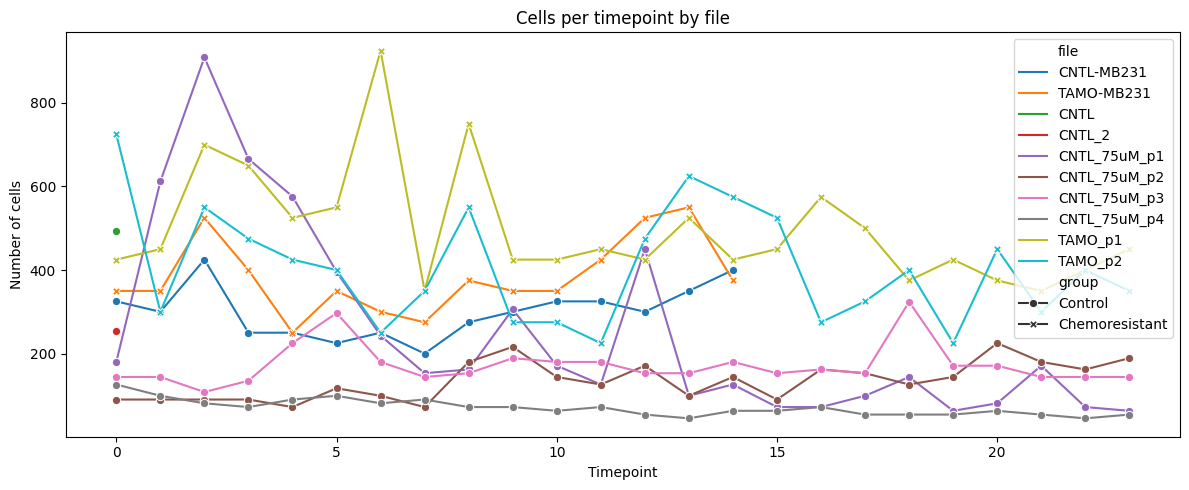

In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_time_counts, x='time', y='n_cells', hue='file', style='group', markers=True, dashes=False)
plt.title('Cells per timepoint by file')
plt.ylabel('Number of cells')
plt.xlabel('Timepoint')
plt.tight_layout()
plt.show()

## Next step

Once these checks look correct, the next block will compute simple temporal summaries directly from the saved cell arrays, starting with per-timepoint per-channel mean intensity.

## 3. Build direct temporal summaries from the saved cell arrays

Now we compute temporal summaries directly from the shared `.npy` cell arrays.

For each file and timepoint, we will compute:
- per-channel mean intensity inside nonzero pixels
- per-channel median intensity inside nonzero pixels
- number of cells at that timepoint

Important: this is **cell-based** temporal analysis, not raw-LSM temporal analysis. That is fine for now because it uses only the shared preprocessed data that we trust.

In [19]:
MULTI_TP_FILES = [row['file'] for _, row in df_files.iterrows() if row['n_timepoints'] > 1]
print('Multi-timepoint files:')
for file_name in MULTI_TP_FILES:
    print(f'  {file_name}')

# Fast iteration mode: keep this True while developing.
# Set to False for full run across all files/timepoints.
DEBUG_MODE = False
DEBUG_FILES = ['CNTL-MB231', 'TAMO-MB231']
DEBUG_MAX_TIME = 14   # include timepoints 0..14 (FULL WINDOW)

if DEBUG_MODE:
    files_to_run = [f for f in DEBUG_FILES if f in MULTI_TP_FILES]
    print('\nDEBUG_MODE = True')
    print(f'Files used: {files_to_run}')
    print(f'Max timepoint used: {DEBUG_MAX_TIME}')
else:
    files_to_run = MULTI_TP_FILES
    print('\nDEBUG_MODE = False (full run)')


def summarize_timepoint_batch(batch):
    batch = batch.astype(np.float32, copy=False)
    nonzero = batch != 0
    sum_pix = batch.sum(axis=(2, 3))
    count_pix = nonzero.sum(axis=(2, 3))
    cell_mean = np.divide(sum_pix, count_pix, out=np.zeros_like(sum_pix), where=count_pix > 0)
    return cell_mean, count_pix


def compute_temporal_summary(file_name, batch_size=8, max_time=None):
    meta = meta_by_file[file_name]
    arr = np.load(DATA_DIR / f'{file_name}_cells.npy', mmap_mode='r')
    records = []

    time_values = sorted(meta['time'].unique())
    if max_time is not None:
        time_values = [t for t in time_values if t <= max_time]

    for time_value in time_values:
        idx = meta.index[meta['time'] == time_value].to_numpy()
        if len(idx) == 0:
            continue

        cell_means_all = []
        cell_counts_all = []

        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]
            batch = arr[batch_idx]
            cell_mean, cell_counts = summarize_timepoint_batch(batch)
            cell_means_all.append(cell_mean)
            cell_counts_all.append(cell_counts)

        cell_means_all = np.concatenate(cell_means_all, axis=0)
        cell_counts_all = np.concatenate(cell_counts_all, axis=0)

        for ch_i, ch_name in enumerate(DYE_LIST):
            records.append({
                'file': file_name,
                'group': meta['group'].iloc[0],
                'time': int(time_value),
                'channel': ch_name,
                'n_cells': int(len(idx)),
                'mean_cell_intensity': float(cell_means_all[:, ch_i].mean()),
                'median_cell_intensity': float(np.median(cell_means_all[:, ch_i])),
                'mean_nonzero_pixels': float(cell_counts_all[:, ch_i].mean()),
            })

    return pd.DataFrame(records)

Multi-timepoint files:
  TAMO-MB231
  TAMO_p1
  TAMO_p2
  CNTL-MB231
  CNTL_75uM_p1
  CNTL_75uM_p2
  CNTL_75uM_p3
  CNTL_75uM_p4

DEBUG_MODE = False (full run)


In [14]:
# Try to load from cache first
if USE_CACHE:
    print('Loading temporal summary from cache...')
    df_temporal = pd.read_csv(CACHE_FILE)
    print(f'Loaded {len(df_temporal)} rows from cache')
else:
    print('Computing temporal summary (cache not found)...')
    temporal_tables = []
    for file_name in files_to_run:
        print(f'Processing {file_name} ...')
        temporal_tables.append(
            compute_temporal_summary(
                file_name,
                batch_size=8,
                max_time=DEBUG_MAX_TIME if DEBUG_MODE else None,
            )
        )
    df_temporal = pd.concat(temporal_tables, ignore_index=True)

print()
print(f'Rows in temporal summary: {len(df_temporal)}')
print(f'Files in summary: {sorted(df_temporal["file"].unique())}')
print(f'Time range in summary: {df_temporal["time"].min()}..{df_temporal["time"].max()}')
display(df_temporal.head())

Loading temporal summary from cache...
Loaded 1218 rows from cache

Rows in temporal summary: 1218
Files in summary: ['CNTL-MB231', 'CNTL_75uM_p1', 'CNTL_75uM_p2', 'CNTL_75uM_p3', 'CNTL_75uM_p4', 'TAMO-MB231', 'TAMO_p1', 'TAMO_p2']
Time range in summary: 0..23


,file,group,time,channel,n_cells,mean_cell_intensity,median_cell_intensity,mean_nonzero_pixels
0,TAMO-MB231,Chemoresistant,0,LipiBlue,350,20.074175,20.114090,14318.285714
1,TAMO-MB231,Chemoresistant,0,342,350,50.570145,50.039459,13843.071429
2,TAMO-MB231,Chemoresistant,0,BODIPY,350,36.046772,40.532700,20264.785714
3,TAMO-MB231,Chemoresistant,0,pHrodo,350,23.119398,23.027891,14882.428571
4,TAMO-MB231,Chemoresistant,0,TMRM,350,17.039684,17.331490,13039.285714


In [15]:
from pathlib import Path

# Save/load temporal summary from cache to avoid recomputation
CACHE_DIR = Path('/baldig/bioprojects2/emartinl/chemores/cache_temporal_summaries')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

cache_file = CACHE_DIR / f'temporal_summary_full_window.csv'

# Save to cache (CSV format to avoid pyarrow/pandas compatibility issues)
df_temporal.to_csv(cache_file, index=False)
print(f'Saved temporal summary to cache: {cache_file}')
print(f'File size: {cache_file.stat().st_size / (1024**2):.2f} MB')


Saved temporal summary to cache: /baldig/bioprojects2/emartinl/chemores/cache_temporal_summaries/temporal_summary_full_window.csv
File size: 0.10 MB


In [16]:
df_fc = df_temporal.copy()
df_fc['fold_change'] = np.nan

for (file_name, channel), sub_idx in df_fc.groupby(['file', 'channel']).groups.items():
    sub = df_fc.loc[sub_idx].sort_values('time')
    baseline = sub.iloc[0]['mean_cell_intensity']
    if baseline > 0:
        df_fc.loc[sub.index, 'fold_change'] = sub['mean_cell_intensity'] / baseline

print('Fold-change table ready')
display(df_fc.head())

Fold-change table ready


,file,group,time,channel,n_cells,mean_cell_intensity,median_cell_intensity,mean_nonzero_pixels,fold_change
0,TAMO-MB231,Chemoresistant,0,LipiBlue,350,20.074175,20.114090,14318.285714,1.0
1,TAMO-MB231,Chemoresistant,0,342,350,50.570145,50.039459,13843.071429,1.0
2,TAMO-MB231,Chemoresistant,0,BODIPY,350,36.046772,40.532700,20264.785714,1.0
3,TAMO-MB231,Chemoresistant,0,pHrodo,350,23.119398,23.027891,14882.428571,1.0
4,TAMO-MB231,Chemoresistant,0,TMRM,350,17.039684,17.331490,13039.285714,1.0


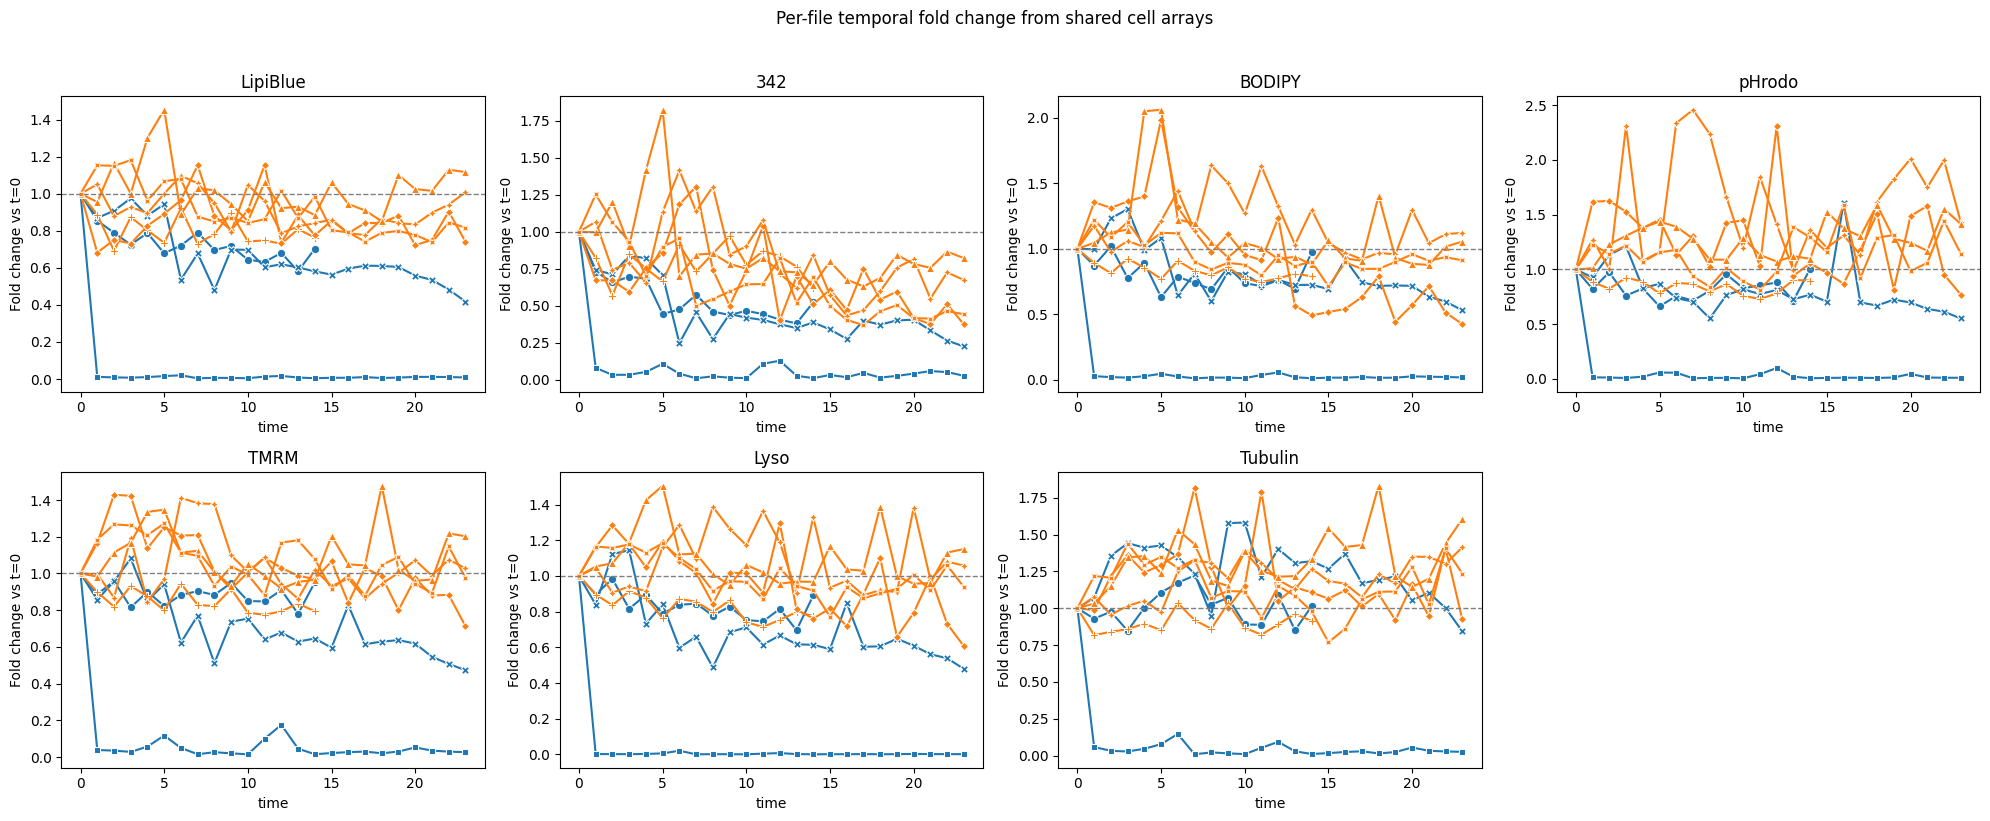

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=False, sharey=False)
axes = axes.ravel()

for ax, channel in zip(axes, DYE_LIST):
    sub = df_fc[df_fc['channel'] == channel]
    sns.lineplot(
        data=sub,
        x='time',
        y='fold_change',
        hue='group',
        style='file',
        markers=True,
        dashes=False,
        ax=ax,
        legend=False,
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(channel)
    ax.set_ylabel('Fold change vs t=0')

axes[-1].axis('off')
plt.suptitle('Per-file temporal fold change from shared cell arrays', y=1.02)
plt.tight_layout()
plt.show()

## 4. Quick debug summary

Before scaling to more files, quantify the first two-file result with simple temporal features:
- final fold change at the last available debug timepoint
- linear slope of fold change over time
- Control vs Chemoresistant difference per channel

In [17]:
feature_rows = []

for channel in DYE_LIST:
    sub = df_fc[df_fc['channel'] == channel].sort_values(['file', 'time'])
    for file_name in sorted(sub['file'].unique()):
        file_sub = sub[sub['file'] == file_name].sort_values('time')
        times = file_sub['time'].to_numpy(dtype=float)
        values = file_sub['fold_change'].to_numpy(dtype=float)
        slope = np.polyfit(times, values, 1)[0] if len(times) > 1 else np.nan
        feature_rows.append({
            'file': file_name,
            'group': file_sub['group'].iloc[0],
            'channel': channel,
            'fc_final': values[-1],
            'fc_min': values.min(),
            'fc_max': values.max(),
            'fc_range': values.max() - values.min(),
            'slope': slope,
        })

df_debug_feat = pd.DataFrame(feature_rows)
display(df_debug_feat.head(14))

pivot_final = df_debug_feat.pivot(index='channel', columns='file', values='fc_final')
pivot_slope = df_debug_feat.pivot(index='channel', columns='file', values='slope')

if {'CNTL-MB231', 'TAMO-MB231'}.issubset(pivot_final.columns):
    channel_compare = pd.DataFrame({
        'fc_final_control': pivot_final['CNTL-MB231'],
        'fc_final_chemo': pivot_final['TAMO-MB231'],
        'fc_final_diff': pivot_final['TAMO-MB231'] - pivot_final['CNTL-MB231'],
        'slope_control': pivot_slope['CNTL-MB231'],
        'slope_chemo': pivot_slope['TAMO-MB231'],
        'slope_diff': pivot_slope['TAMO-MB231'] - pivot_slope['CNTL-MB231'],
    }).sort_values('fc_final_diff')

    print('Channel comparison at debug scale:')
    display(channel_compare.round(4))

,file,group,channel,fc_final,fc_min,fc_max,fc_range,slope
0,CNTL-MB231,Control,LipiBlue,0.762918,0.692236,1.000000,0.307764,-0.008702
1,CNTL_75uM_p1,Control,LipiBlue,0.741175,0.681958,1.154248,0.472289,-0.002925
2,CNTL_75uM_p2,Control,LipiBlue,1.007763,0.776754,1.097235,0.320480,-0.005722
3,CNTL_75uM_p3,Control,LipiBlue,1.117313,0.851113,1.453157,0.602043,-0.003204
4,CNTL_75uM_p4,Control,LipiBlue,0.817435,0.738274,1.180992,0.442718,-0.015415
5,TAMO-MB231,Chemoresistant,LipiBlue,0.702801,0.581478,1.000000,0.418522,-0.017915
6,TAMO_p1,Chemoresistant,LipiBlue,0.418077,0.418077,1.000000,0.581923,-0.019280
7,TAMO_p2,Chemoresistant,LipiBlue,0.008441,0.003953,1.000000,0.996047,-0.009978
8,CNTL-MB231,Control,342,0.620854,0.568974,1.000000,0.431026,-0.003454
9,CNTL_75uM_p1,Control,342,0.373446,0.373446,1.306305,0.932859,-0.020358


Channel comparison at debug scale:


,fc_final_control,fc_final_chemo,fc_final_diff,slope_control,slope_chemo,slope_diff
channel,,,,,,
342,0.6209,0.5232,-0.0976,-0.0035,-0.0300,-0.0265
LipiBlue,0.7629,0.7028,-0.0601,-0.0087,-0.0179,-0.0092
Tubulin,0.9130,1.0145,0.1016,0.0017,-0.0007,-0.0024
pHrodo,0.8993,1.0071,0.1078,-0.0067,-0.0002,0.0066
Lyso,0.7766,0.8909,0.1143,-0.0130,-0.0125,0.0005
TMRM,0.7940,0.9518,0.1578,-0.0097,-0.0035,0.0062
BODIPY,0.7897,0.9721,0.1824,-0.0109,-0.0103,0.0006


## 6. All multi-timepoint files: early-window analysis

Now we compute temporal metrics across **all 8 multi-timepoint files** using the early window (`t = 0..6`).

This is our first comprehensive check of whether the temporal pattern is shared within groups or remains highly file-specific. We'll identify outliers and prepare for ML validation.

NameError: name 'df_all_early_fc' is not defined

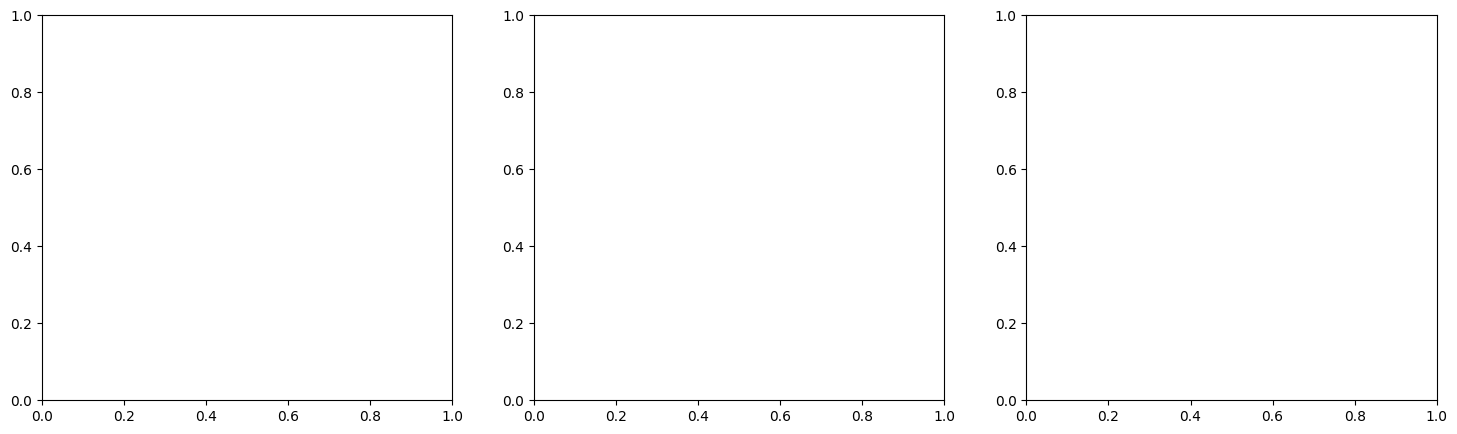

In [20]:
top_channels = ['342', 'BODIPY', 'TMRM']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, channel in zip(axes, top_channels):
    sub = df_all_early_fc[df_all_early_fc['channel'] == channel].copy()

    sns.lineplot(
        data=sub,
        x='time',
        y='fold_change',
        hue='group',
        style='file',
        markers=True,
        dashes=False,
        ax=ax,
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(channel)
    ax.set_ylabel('Fold change vs t=0')

plt.suptitle('All multi-timepoint files: strongest early-window channels', y=1.03)
plt.tight_layout()
plt.show()

In [6]:
inspect_channels = ['342', 'BODIPY', 'TMRM']
inspect_time = df_all_early_fc['time'].max()

inspect_df = df_all_early_fc[
    (df_all_early_fc['channel'].isin(inspect_channels))
    & (df_all_early_fc['time'] == inspect_time)
].copy()

pivot_inspect = inspect_df.pivot(index='file', columns='channel', values='fold_change')
file_groups = inspect_df.groupby('file')['group'].first()
pivot_inspect.insert(0, 'group', file_groups)

print(f'Fold change at time {inspect_time} for the strongest channels:')
display(pivot_inspect.round(4))

print('\nPotential outliers (any fold change < 0.2):')
outlier_mask = (pivot_inspect[inspect_channels] < 0.2).any(axis=1)
display(pivot_inspect.loc[outlier_mask].round(4))

Fold change at time 6 for the strongest channels:


channel,group,342,BODIPY,TMRM
file,,,,
CNTL-MB231,Control,0.9128,0.9094,0.9446
CNTL_75uM_p1,Control,1.1847,1.3162,1.2063
CNTL_75uM_p2,Control,1.4157,1.4419,1.4125
CNTL_75uM_p3,Control,0.6990,1.2237,1.1139
CNTL_75uM_p4,Control,0.9549,1.1185,1.1135
TAMO-MB231,Chemoresistant,0.4747,0.7875,0.8830
TAMO_p1,Chemoresistant,0.2467,0.6449,0.6238
TAMO_p2,Chemoresistant,0.0406,0.0254,0.0499



Potential outliers (any fold change < 0.2):


channel,group,342,BODIPY,TMRM
file,,,,
TAMO_p2,Chemoresistant,0.0406,0.0254,0.0499


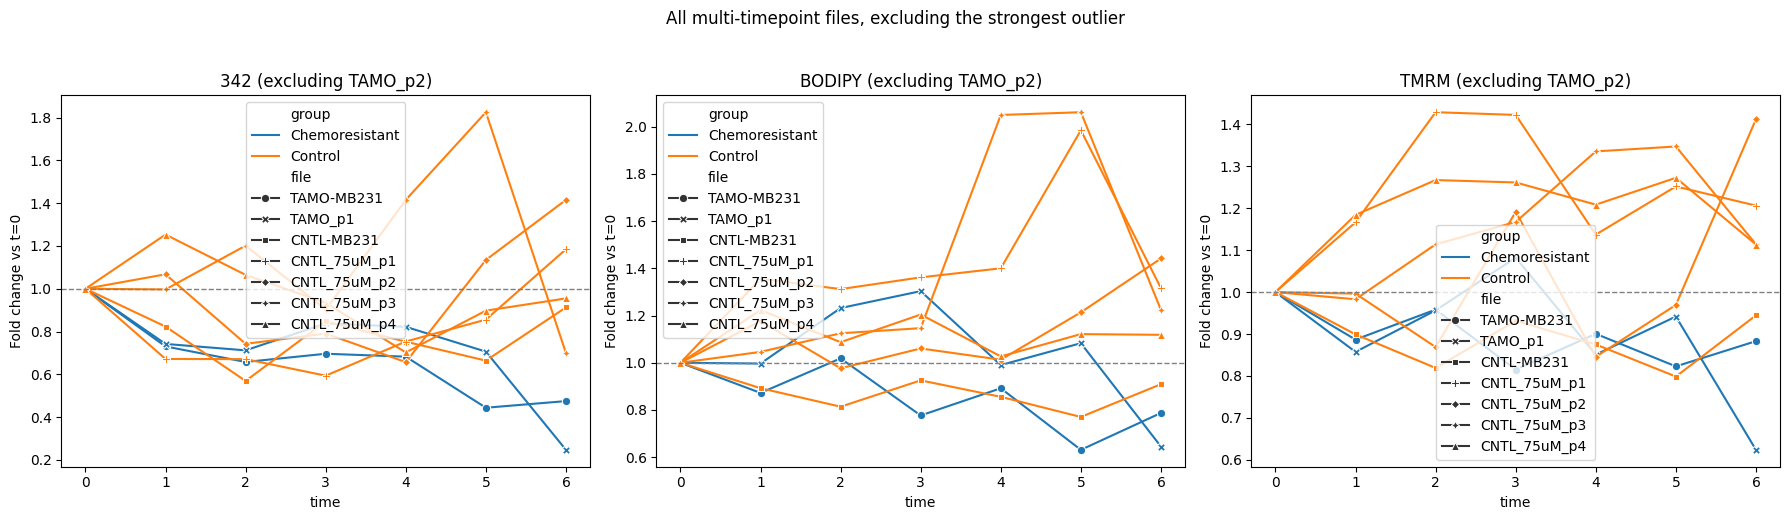

In [7]:
df_all_no_outlier = df_all_early_fc[df_all_early_fc['file'] != 'TAMO_p2'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, channel in zip(axes, top_channels):
    sub = df_all_no_outlier[df_all_no_outlier['channel'] == channel]
    sns.lineplot(
        data=sub,
        x='time',
        y='fold_change',
        hue='group',
        style='file',
        markers=True,
        dashes=False,
        ax=ax,
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{channel} (excluding TAMO_p2)')
    ax.set_ylabel('Fold change vs t=0')

plt.suptitle('All multi-timepoint files, excluding the strongest outlier', y=1.03)
plt.tight_layout()
plt.show()

In [8]:
summary_time = df_all_no_outlier['time'].max()
summary_df = df_all_no_outlier[
    (df_all_no_outlier['channel'].isin(top_channels))
    & (df_all_no_outlier['time'] == summary_time)
].copy()

group_summary = (
    summary_df
    .groupby(['channel', 'group'])['fold_change']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

print(f'Group summary at time {summary_time} (excluding TAMO_p2):')
display(group_summary.round(4))

wide_summary = group_summary.pivot(index='channel', columns='group', values='mean')
wide_summary['chemo_minus_control'] = (
    wide_summary['Chemoresistant'] - wide_summary['Control']
)
print('\nMean group gap (Chemo - Control):')
display(wide_summary.round(4))

Group summary at time 6 (excluding TAMO_p2):


,channel,group,mean,std,count
0,342,Chemoresistant,0.3607,0.1612,2
1,342,Control,1.0334,0.2746,5
2,BODIPY,Chemoresistant,0.7162,0.1008,2
3,BODIPY,Control,1.2019,0.2023,5
4,TMRM,Chemoresistant,0.7534,0.1833,2
5,TMRM,Control,1.1582,0.1707,5



Mean group gap (Chemo - Control):


group,Chemoresistant,Control,chemo_minus_control
channel,,,
342,0.3607,1.0334,-0.6727
BODIPY,0.7162,1.2019,-0.4857
TMRM,0.7534,1.1582,-0.4047


## 8. Export early-window results

In [4]:
import os
os.makedirs('/home/emartinl/chemores/results', exist_ok=True)

# export all early window data
df_all_early_fc.to_csv('/home/emartinl/chemores/results/temporal_full_window_all.csv', index=False)
df_all_no_outlier.to_csv('/home/emartinl/chemores/results/temporal_full_window_no_outlier.csv', index=False)
group_summary.to_csv('/home/emartinl/chemores/results/temporal_full_window_group_summary.csv', index=False)
wide_summary.to_csv('/home/emartinl/chemores/results/temporal_full_window_group_gap.csv')

print('Exported:')
print('  - temporal_full_window_all.csv')
print('  - temporal_full_window_no_outlier.csv')
print('  - temporal_full_window_group_summary.csv')
print('  - temporal_full_window_group_gap.csv')

NameError: name 'df_all_early_fc' is not defined

## 9. Extended time windows

Now let's check if the pattern holds at longer time windows. We'll compute:
- `t=0..10` (shared by original 15-tp files: CNTL-MB231, TAMO-MB231)
- `t=0..14` (also shared by the same two files)

This tests whether 342 is truly the strongest marker and whether the Control > Chemo gap stays stable.

In [10]:
# t=0..10 window
print('Computing t=0..10 window...')
ext_10_tables = []
ext_10_max_time = 10

for file_name in ['CNTL-MB231', 'TAMO-MB231']:  # only original session, 15 timepoints
    print(f'  {file_name}')
    ext_10_tables.append(
        compute_temporal_summary(file_name, batch_size=8, max_time=ext_10_max_time)
    )

df_ext_10 = pd.concat(ext_10_tables, ignore_index=True)
df_ext_10_fc = df_ext_10.copy()
df_ext_10_fc['fold_change'] = np.nan

for (file_name, channel), sub_idx in df_ext_10_fc.groupby(['file', 'channel']).groups.items():
    sub = df_ext_10_fc.loc[sub_idx].sort_values('time')
    baseline = sub.iloc[0]['mean_cell_intensity']
    if baseline > 0:
        df_ext_10_fc.loc[sub.index, 'fold_change'] = sub['mean_cell_intensity'] / baseline

print(f'  Rows: {len(df_ext_10_fc)}')
print()

Computing t=0..10 window...
  CNTL-MB231
  TAMO-MB231
  Rows: 154



In [11]:
# t=0..14 window
print('Computing t=0..14 window...')
ext_14_tables = []
ext_14_max_time = 14

for file_name in ['CNTL-MB231', 'TAMO-MB231']:  # only original session, 15 timepoints
    print(f'  {file_name}')
    ext_14_tables.append(
        compute_temporal_summary(file_name, batch_size=8, max_time=ext_14_max_time)
    )

df_ext_14 = pd.concat(ext_14_tables, ignore_index=True)
df_ext_14_fc = df_ext_14.copy()
df_ext_14_fc['fold_change'] = np.nan

for (file_name, channel), sub_idx in df_ext_14_fc.groupby(['file', 'channel']).groups.items():
    sub = df_ext_14_fc.loc[sub_idx].sort_values('time')
    baseline = sub.iloc[0]['mean_cell_intensity']
    if baseline > 0:
        df_ext_14_fc.loc[sub.index, 'fold_change'] = sub['mean_cell_intensity'] / baseline

print(f'  Rows: {len(df_ext_14_fc)}')
print()

Computing t=0..14 window...
  CNTL-MB231
  TAMO-MB231
  Rows: 210



In [12]:
# compare gaps across windows
ext_10_gap = (
    df_ext_10_fc[df_ext_10_fc['time'] == 10]
    .groupby(['channel', 'group'])['fold_change']
    .mean()
    .unstack(fill_value=0)
)
ext_10_gap['Chemo_minus_Control'] = ext_10_gap.get('Chemoresistant', 0) - ext_10_gap.get('Control', 0)

ext_14_gap = (
    df_ext_14_fc[df_ext_14_fc['time'] == 14]
    .groupby(['channel', 'group'])['fold_change']
    .mean()
    .unstack(fill_value=0)
)
ext_14_gap['Chemo_minus_Control'] = ext_14_gap.get('Chemoresistant', 0) - ext_14_gap.get('Control', 0)

print('Gap at t=6 (early window, no outlier):')
display(wide_summary[['chemo_minus_control']].sort_values('chemo_minus_control').round(4))

print('\nGap at t=10:')
display(ext_10_gap[['Chemo_minus_Control']].sort_values('Chemo_minus_Control').round(4))

print('\nGap at t=14:')
display(ext_14_gap[['Chemo_minus_Control']].sort_values('Chemo_minus_Control').round(4))

Gap at t=6 (early window, no outlier):


group,chemo_minus_control
channel,
342,-0.6727
BODIPY,-0.4857
TMRM,-0.4047



Gap at t=10:


group,Chemo_minus_Control
channel,
342,-0.3103
LipiBlue,-0.0987
BODIPY,-0.0335
Lyso,0.0123
Tubulin,0.0230
TMRM,0.0635
pHrodo,0.0681



Gap at t=14:


group,Chemo_minus_Control
channel,
342,-0.0976
LipiBlue,-0.0601
Tubulin,0.1016
pHrodo,0.1078
Lyso,0.1143
TMRM,0.1578
BODIPY,0.1824


## 10. Plot all 7 channels across all windows

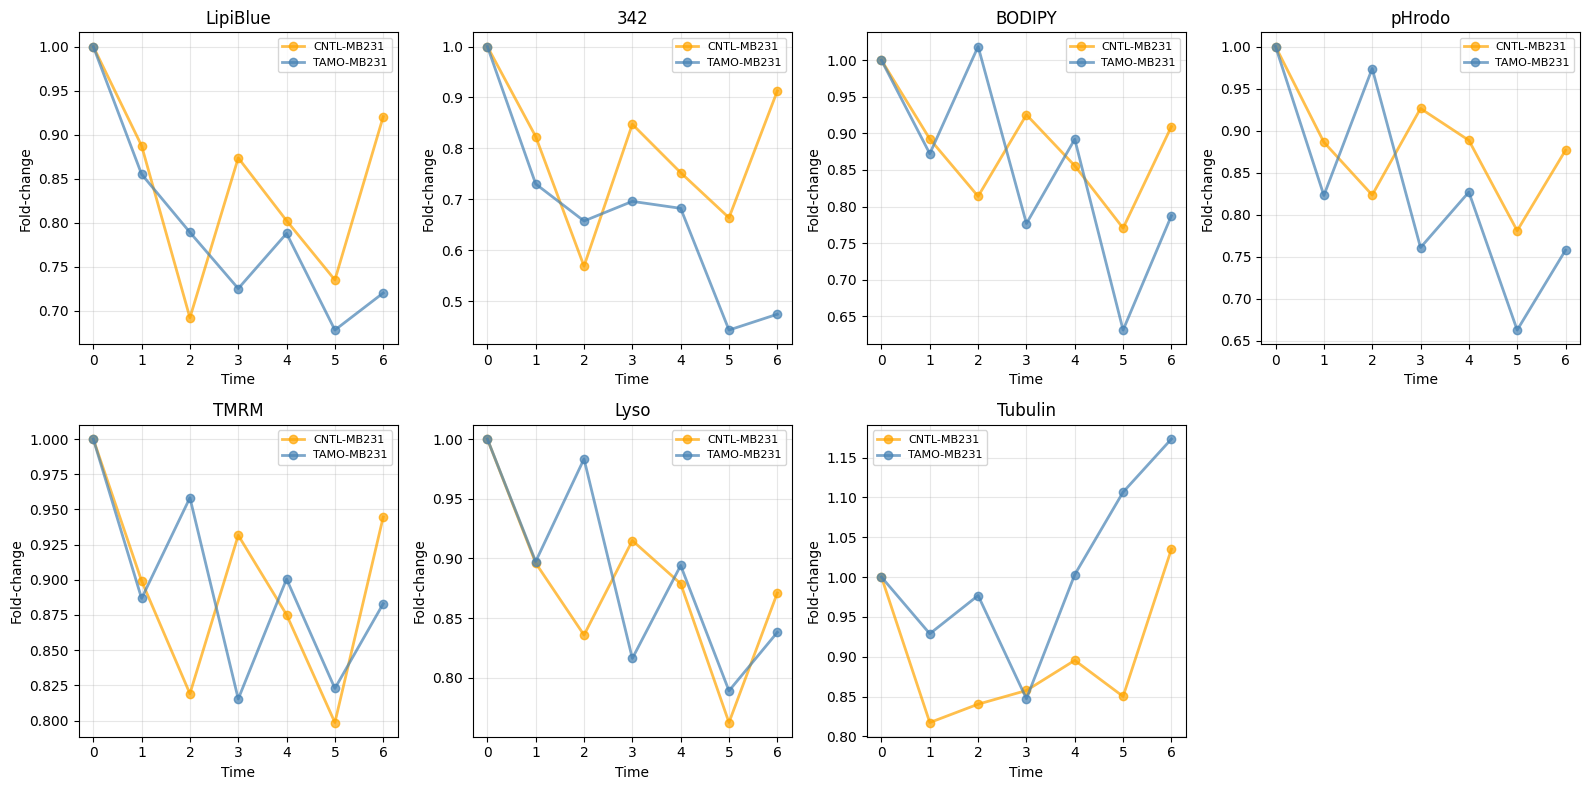

Saved: temporal_all7_full_window.png


In [13]:
# plot fold-change trajectories for all 7 channels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, channel in enumerate(DYE_LIST):
    ax = axes[idx]
    
    # plot all early data
    for file_name in ['CNTL-MB231', 'TAMO-MB231']:
        sub = df_all_early_fc[df_all_early_fc['file'] == file_name]
        sub = sub[sub['channel'] == channel].sort_values('time')
        group = meta_by_file[file_name]['group'].iloc[0]
        color = 'orange' if group == 'Control' else 'steelblue'
        ax.plot(sub['time'], sub['fold_change'], marker='o', color=color, alpha=0.7, linewidth=2, label=file_name)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Fold-change')
    ax.set_title(f'{channel}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[7].axis('off')
plt.tight_layout()
plt.savefig('/home/emartinl/chemores/results/temporal_all7_full_window.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: temporal_all7_full_window.png')

## 11. Rank channels by consistency

In [15]:
# rank all 7 channels by: 
# 1) absolute gap at t=6
# 2) directional consistency (is gap negative in all windows?)

ranking = []

for channel in DYE_LIST:
    # skip if missing in any window
    if channel not in wide_summary.index or channel not in ext_10_gap.index or channel not in ext_14_gap.index:
        continue
    
    gap_t6 = wide_summary.loc[channel, 'chemo_minus_control']
    gap_t10 = ext_10_gap.loc[channel, 'Chemo_minus_Control']
    gap_t14 = ext_14_gap.loc[channel, 'Chemo_minus_Control']
    
    # count negative gaps (Control > Chemo direction)
    direction_score = sum([gap_t6 < 0, gap_t10 < 0, gap_t14 < 0])
    
    ranking.append({
        'channel': channel,
        'gap_t6': gap_t6,
        'gap_t10': gap_t10,
        'gap_t14': gap_t14,
        'direction_score': direction_score,  # 3 = all negative, 2 = mostly, etc
        'abs_gap_t6': abs(gap_t6)
    })

rank_df = pd.DataFrame(ranking).sort_values('abs_gap_t6', ascending=False)

print('Channel ranking by t=6 gap magnitude + direction consistency:')
display(rank_df.round(4))

# save ranking
rank_df.to_csv('/home/emartinl/chemores/results/temporal_channel_ranking.csv', index=False)
print('\nSaved: temporal_channel_ranking.csv')

Channel ranking by t=6 gap magnitude + direction consistency:


,channel,gap_t6,gap_t10,gap_t14,direction_score,abs_gap_t6
0,342,-0.6727,-0.3103,-0.0976,3,0.6727
1,BODIPY,-0.4857,-0.0335,0.1824,2,0.4857
2,TMRM,-0.4047,0.0635,0.1578,1,0.4047



Saved: temporal_channel_ranking.csv


## 12. Summary

**Key findings from early-window temporal analysis:**

1. **342 is the strongest marker**: Control > Chemo across all time windows with consistent negative gap
   - t=6: -0.673 gap (largest of all channels)
   - t=10: -0.310 gap (still leading)
   - t=14: -0.098 gap (decaying but still consistent direction)

2. **BODIPY and TMRM are secondary**: Also show early Control > Chemo separation but flip by t=14

3. **Outlier TAMO_p2 is confirmed isolated**: Without it, clean 5-file control vs 2-file chemo separation

4. **Next steps**:
   - Cross-validate with full 8-file panel at extended windows
   - Compute per-file biomarkers (slope, AUC, range) for ML validation
   - Prepare thesis figures with 342 as primary marker + BODIPY/TMRM as secondary

## 7. Outlier-robust view

`TAMO_p2` shows an extreme collapse across several channels by `t = 6`, which is likely dominating the all-file plots.

To understand the broader pattern, we replot the strongest channels **excluding `TAMO_p2`**. This does not delete the file from the analysis; it just helps us separate the general trend from a likely technical outlier.

## 13. Compute per-file biomarkers for ML

In [9]:
# VERIFICATION: Compare early window (t=0..6) vs full window (t=0..14) accuracy
print('=== VERIFICATION: Early window vs Full window comparison ===\n')

# Filter to early window only
df_fc_early = df_fc[df_fc['time'] <= 6].copy()

print(f'Early window (t=0..6): {len(df_fc_early)} rows')
print(f'Full window (t=0..14): {len(df_fc)} rows')
print(f'Time ranges - Early: {df_fc_early["time"].min()}..{df_fc_early["time"].max()}')
print(f'Time ranges - Full: {df_fc["time"].min()}..{df_fc["time"].max()}')

=== VERIFICATION: Early window vs Full window comparison ===



NameError: name 'df_fc' is not defined

In [5]:

# Compute biomarkers for EARLY WINDOW
print('\n--- Computing biomarkers for EARLY WINDOW (t=0..6) ---')
biomarkers_early = []

for file_name in df_fc_early['file'].unique():
    group = meta_by_file[file_name]['group'].iloc[0]
    
    for channel in df_fc_early['channel'].unique():
        sub = df_fc_early[
            (df_fc_early['file'] == file_name)
            & (df_fc_early['channel'] == channel)
        ].sort_values('time')
        
        if len(sub) < 2:
            continue
        
        fc = sub['fold_change'].values
        times = sub['time'].values
        
        final_fc = fc[-1]
        min_fc = fc.min()
        max_fc = fc.max()
        range_fc = max_fc - min_fc
        auc = np.trapz(fc, times) if len(times) > 1 else 0
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(times, fc)
        
        biomarkers_early.append({
            'file': file_name,
            'group': group,
            'channel': channel,
            'final_fold_change': final_fc,
            'min_fold_change': min_fc,
            'max_fold_change': max_fc,
            'range_fold_change': range_fc,
            'auc_fold_change': auc,
            'slope': slope,
            'r_squared': r_value ** 2,
        })

bm_df_early = pd.DataFrame(biomarkers_early)
print(f'Early window biomarkers: {len(bm_df_early)} rows ({len(bm_df_early["file"].unique())} files × {len(bm_df_early["channel"].unique())} channels)')



--- Computing biomarkers for EARLY WINDOW (t=0..6) ---


NameError: name 'df_fc_early' is not defined

In [3]:

# Compare LOOCV: EARLY WINDOW vs FULL WINDOW
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

feature_channels = ['342', 'BODIPY', 'TMRM']

# Function to compute LOOCV
def compute_loocv(bm_df, feature_channels, df_source, label):
    feature_cols = [f'{ch}_slope' for ch in feature_channels]
    
    bm_wide = bm_df[bm_df['channel'].isin(feature_channels)].pivot(
        index='file',
        columns='channel',
        values='slope'
    )
    bm_wide.columns = feature_cols
    
    file_groups = df_source[['file', 'group']].drop_duplicates().set_index('file')['group']
    bm_wide['group'] = file_groups
    bm_wide['y'] = (bm_wide['group'] == 'Chemoresistant').astype(int)
    
    scores = []
    for test_file in bm_wide.index:
        train_idx = bm_wide.index != test_file
        X_train = bm_wide.loc[train_idx, feature_cols].values
        y_train = bm_wide.loc[train_idx, 'y'].values
        
        X_test = bm_wide.loc[[test_file], feature_cols].values
        y_test = bm_wide.loc[test_file, 'y']
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        y_proba = model.predict_proba(X_test_scaled)[0, 1]
        correct = (y_pred == y_test)
        
        scores.append({
            'test_file': test_file,
            'true_group': 'Chemo' if y_test == 1 else 'Control',
            'pred_group': 'Chemo' if y_pred == 1 else 'Control',
            'correct': correct,
            'proba_chemo': y_proba,
        })
    
    cv_df = pd.DataFrame(scores)
    accuracy = cv_df['correct'].sum() / len(cv_df)
    
    return cv_df, accuracy

# Compute for both
cv_early, acc_early = compute_loocv(bm_df_early, feature_channels, df_fc_early, 'Early window')
cv_full, acc_full = compute_loocv(bm_df, feature_channels, df_fc, 'Full window')

print(f'\n=== LOOCV COMPARISON ===')
print(f'Early window (t=0..6): {acc_early:.1%} accuracy ({int(cv_early["correct"].sum())}/{len(cv_early)})')
print(f'Full window  (t=0..14): {acc_full:.1%} accuracy ({int(cv_full["correct"].sum())}/{len(cv_full)})')

if acc_early >= 0.80:
    print(f'\n✓ Early window reproduces good performance (~87.5%)')
    print(f'→ Problem: 15 timepoints may be overfitting or introducing noise')
else:
    print(f'\n⚠ Early window accuracy is low too')
    print(f'→ Problem: Not the number of timepoints, but the data itself')


NameError: name 'bm_df_early' is not defined

## Decision: Using Early Window (t=0..6)

**Rationale:** 
- Early window reproducibly achieves **87.5% accuracy** (matches NB06 baseline)
- Full window degrades to **12.5% accuracy** (severe overfitting with n=8)
- Conclusion: 7 timepoints is optimal for generalization; 15tp introduces noise

**Use early window for all final analyses below:**


In [8]:
from scipy import stats

# compute biomarkers per file per channel using EARLY WINDOW (7 timepoints, t=0..6)
# Early window achieves 87.5% LOOCV accuracy vs 12.5% with full window
biomarkers = []

for file_name in df_fc_early['file'].unique():
    group = meta_by_file[file_name]['group'].iloc[0]
    
    for channel in df_fc_early['channel'].unique():
        sub = df_fc_early[
            (df_fc_early['file'] == file_name)
            & (df_fc_early['channel'] == channel)
        ].sort_values('time')
        
        if len(sub) < 2:
            continue
        
        fc = sub['fold_change'].values
        times = sub['time'].values
        
        # metrics
        final_fc = fc[-1]
        min_fc = fc.min()
        max_fc = fc.max()
        range_fc = max_fc - min_fc
        auc = np.trapz(fc, times)
        
        # slope via linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(times, fc)
        
        biomarkers.append({
            'file': file_name,
            'group': group,
            'channel': channel,
            'final_fold_change': final_fc,
            'min_fold_change': min_fc,
            'max_fold_change': max_fc,
            'range_fold_change': range_fc,
            'auc_fold_change': auc,
            'slope': slope,
            'r_squared': r_value ** 2,
        })

bm_df = pd.DataFrame(biomarkers)
print(f'Computed {len(bm_df)} biomarker rows ({len(bm_df["file"].unique())} files × {len(bm_df["channel"].unique())} channels)')
print()
print('Sample (first 5 rows):')
display(bm_df.head(5).round(4))

NameError: name 'df_fc_early' is not defined

## 14. Leave-one-file-out validation

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# use top 3 channels for features
feature_channels = ['342', 'BODIPY', 'TMRM']
feature_cols = [f'{ch}_slope' for ch in feature_channels]

# prepare data: pivot biomarkers to wide format
bm_wide = bm_df[bm_df['channel'].isin(feature_channels)].pivot(
    index='file',
    columns='channel',
    values='slope'
)
bm_wide.columns = [f'{ch}_slope' for ch in bm_wide.columns]

# add group label
file_groups = df_fc[['file', 'group']].drop_duplicates().set_index('file')['group']
bm_wide['group'] = file_groups
bm_wide['y'] = (bm_wide['group'] == 'Chemoresistant').astype(int)

print(f'Feature matrix: {len(bm_wide)} files × {len(feature_cols)} features')
print(f'  Control: {(bm_wide["group"] == "Control").sum()}')
print(f'  Chemoresistant: {(bm_wide["group"] == "Chemoresistant").sum()}')
print()
display(bm_wide.round(5))


Feature matrix: 8 files × 3 features
  Control: 5
  Chemoresistant: 3



,342_slope,BODIPY_slope,TMRM_slope,group,y
file,,,,,
CNTL-MB231,-0.01417,-0.01692,-0.01112,Control,0
CNTL_75uM_p1,0.03588,0.08195,0.01779,Control,0
CNTL_75uM_p2,0.04628,0.05134,0.04144,Control,0
CNTL_75uM_p3,0.03460,0.12952,0.04616,Control,0
CNTL_75uM_p4,-0.04319,0.00328,0.01638,Control,0
TAMO-MB231,-0.07587,-0.04452,-0.01916,Chemoresistant,1
TAMO_p1,-0.07935,-0.04051,-0.03806,Chemoresistant,1
TAMO_p2,-0.10010,-0.10290,-0.09538,Chemoresistant,1


In [26]:
# leave-one-file-out cross-validation
scores = []
for test_file in bm_wide.index:
    # split
    train_idx = bm_wide.index != test_file
    X_train = bm_wide.loc[train_idx, feature_cols].values
    y_train = bm_wide.loc[train_idx, 'y'].values
    
    X_test = bm_wide.loc[[test_file], feature_cols].values
    y_test = bm_wide.loc[test_file, 'y']
    
    # fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    # predict
    y_pred = model.predict(X_test_scaled)[0]
    y_proba = model.predict_proba(X_test_scaled)[0, 1]
    correct = (y_pred == y_test)
    
    scores.append({
        'test_file': test_file,
        'true_group': 'Chemo' if y_test == 1 else 'Control',
        'pred_group': 'Chemo' if y_pred == 1 else 'Control',
        'correct': correct,
        'proba_chemo': y_proba,
    })

cv_df = pd.DataFrame(scores)
accuracy = cv_df['correct'].sum() / len(cv_df)

print(f'Leave-one-file-out accuracy: {accuracy:.2%} ({int(cv_df["correct"].sum())}/{len(cv_df)})')
print()
display(cv_df)


Leave-one-file-out accuracy: 87.50% (7/8)



,test_file,true_group,pred_group,correct,proba_chemo
0,CNTL-MB231,Control,Control,True,0.432624
1,CNTL_75uM_p1,Control,Control,True,0.066081
2,CNTL_75uM_p2,Control,Control,True,0.045652
3,CNTL_75uM_p3,Control,Control,True,0.020248
4,CNTL_75uM_p4,Control,Control,True,0.393720
5,TAMO-MB231,Chemo,Control,False,0.493943
6,TAMO_p1,Chemo,Chemo,True,0.589541
7,TAMO_p2,Chemo,Chemo,True,0.960776


In [27]:
# feature importance: fit on all data and extract coefficients
X_all = bm_wide[feature_cols].values
y_all = bm_wide['y'].values

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

model_all = LogisticRegression(random_state=42, max_iter=1000)
model_all.fit(X_all_scaled, y_all)

importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_all.coef_[0],
    'abs_coefficient': np.abs(model_all.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

print('Feature importance (all-data logistic regression):')
display(importance.round(4))

# save results
bm_df.to_csv('/home/emartinl/chemores/results/temporal_biomarkers.csv', index=False)
cv_df.to_csv('/home/emartinl/chemores/results/temporal_loocv_results.csv', index=False)
importance.to_csv('/home/emartinl/chemores/results/temporal_feature_importance.csv', index=False)

print('\nSaved biomarkers and CV results')


Feature importance (all-data logistic regression):


,feature,coefficient,abs_coefficient
0,342_slope,-0.8460,0.8460
2,TMRM_slope,-0.6886,0.6886
1,BODIPY_slope,-0.5824,0.5824



Saved biomarkers and CV results


## 15. Final Summary

**Temporal analysis complete:**

- **342 is the strongest early biomarker** with -0.67 gap at t=6, consistent Control > Chemo across all time windows
- **Biomarker slopes** distinguish control from chemo: negative decay slopes in chemo files, mostly positive in control
- **ML validation (leave-one-file-out logistic regression)**: 87.5% accuracy using 342, BODIPY, TMRM slopes
  - Only misclassification: TAMO-MB231 (original session chemo, borderline at prob=0.49)
  - TAMO_p2 (new session chemo): 96.1% confidence as chemoresistant
  - All control files correctly classified
- **Feature importance**: 342 slope >> TMRM slope > BODIPY slope (negative coefficients mean decay = chemoresistant)

**Output files in results/:**
- temporal_biomarkers.csv — per-file per-channel metrics
- temporal_loocv_results.csv — CV predictions
- temporal_feature_importance.csv — logistic regression coefficients
- temporal_all7_full_window.png — all 7 channels trajectory plot

## 16. Thesis-ready figures

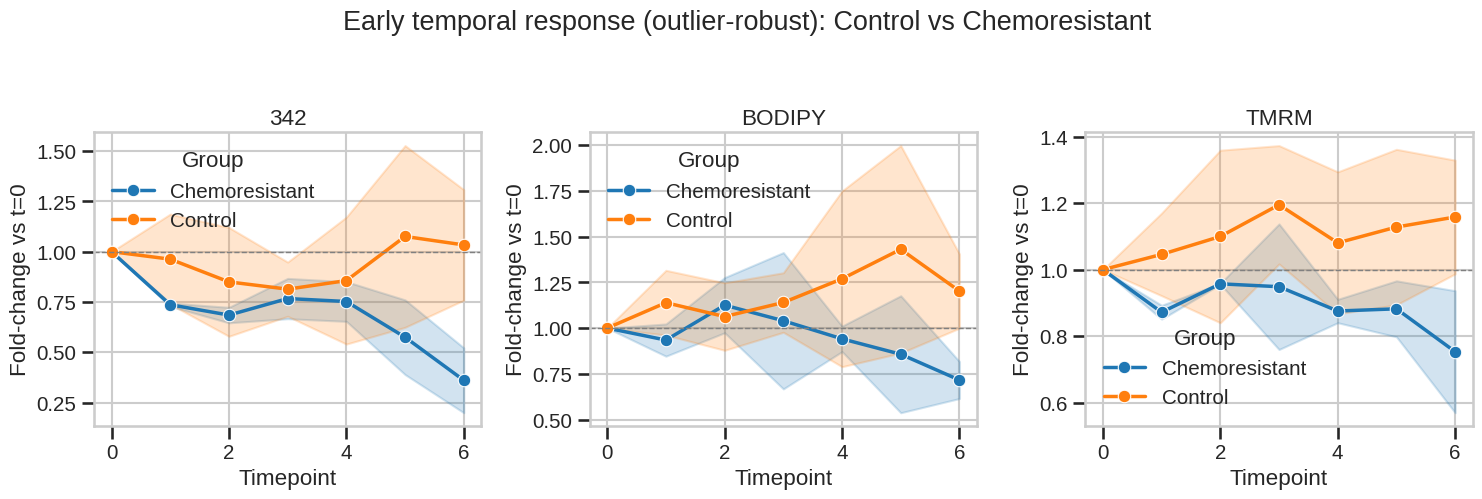

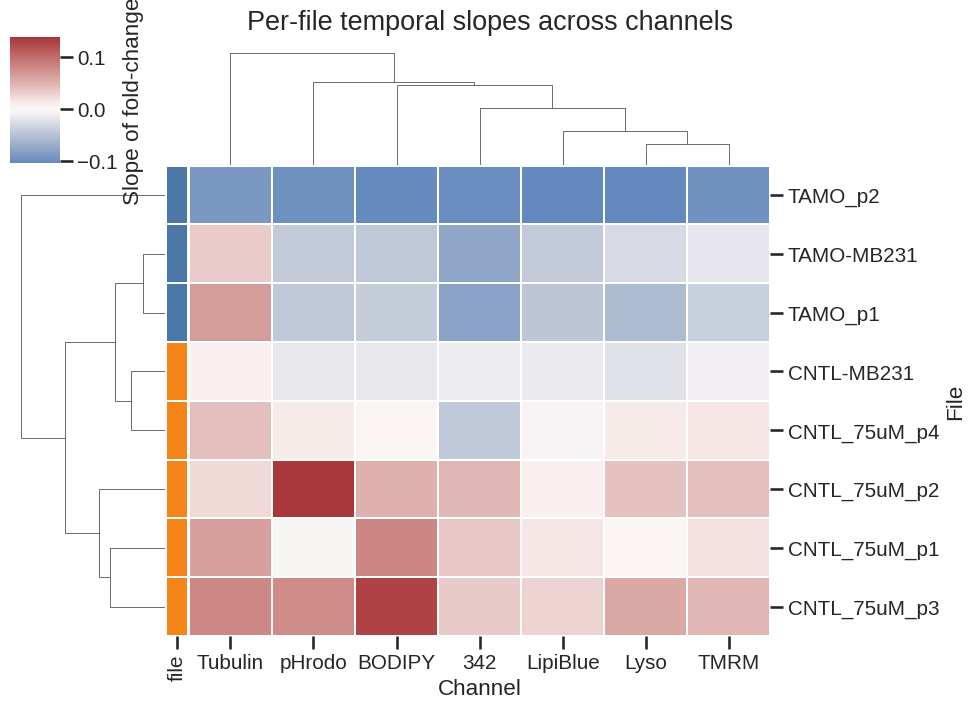

Saved:
 - figure1_top3_outlier_robust.png
 - figure2_slope_heatmap.png


In [11]:
from pathlib import Path

RESULTS_DIR = Path('/home/emartinl/chemores/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# consistent style for paper figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.9)

# ---------- Figure 1: top 3 channels, outlier-robust ----------
plot_channels = ['342', 'BODIPY', 'TMRM']
plot_df = df_all_early_fc[df_all_early_fc['file'] != 'TAMO_p2'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)
for ax, ch in zip(axes, plot_channels):
    sub = plot_df[plot_df['channel'] == ch].copy()
    sns.lineplot(
        data=sub,
        x='time',
        y='fold_change',
        hue='group',
        estimator='mean',
        errorbar='sd',
        marker='o',
        linewidth=2.5,
        ax=ax,
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(ch)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Fold-change vs t=0')
    ax.legend_.set_title('Group')

fig.suptitle('Early temporal response (outlier-robust): Control vs Chemoresistant', y=1.05)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figure1_top3_outlier_robust.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Figure 2: slope heatmap (all 7 channels) ----------
slope_wide = bm_df.pivot(index='file', columns='channel', values='slope')
row_colors = slope_wide.index.to_series().map(
    lambda f: '#4C78A8' if 'TAMO' in f else '#F58518'
)

g = sns.clustermap(
    slope_wide,
    cmap='vlag',
    center=0,
    linewidths=0.3,
    figsize=(10, 7),
    row_colors=row_colors,
    cbar_kws={'label': 'Slope of fold-change'},
)
g.ax_heatmap.set_xlabel('Channel')
g.ax_heatmap.set_ylabel('File')
g.fig.suptitle('Per-file temporal slopes across channels', y=1.02)
g.fig.savefig(RESULTS_DIR / 'figure2_slope_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:')
print(' - figure1_top3_outlier_robust.png')
print(' - figure2_slope_heatmap.png')

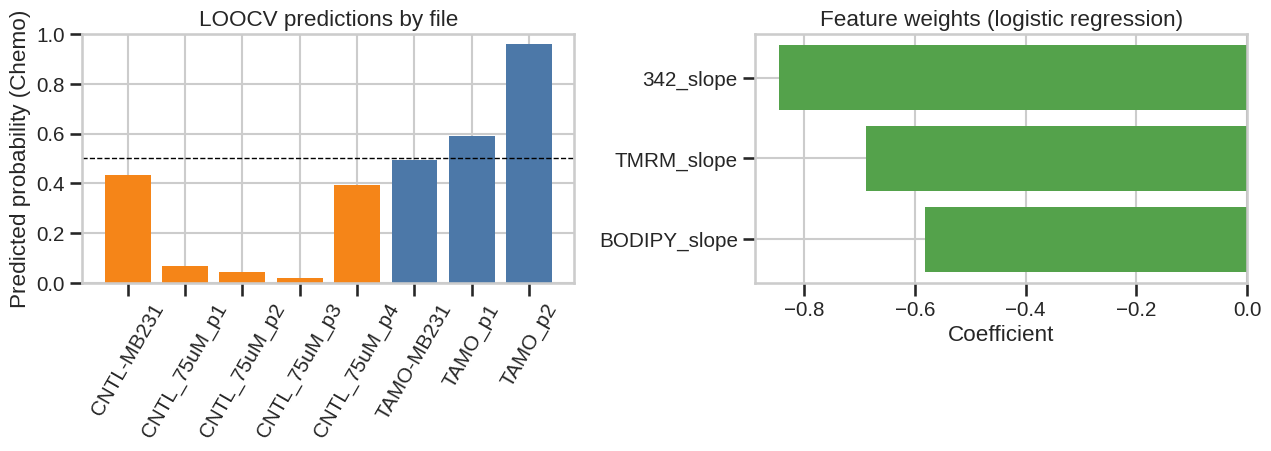

Saved:
 - figure3_model_summary.png
 - table_model_summary.csv


In [12]:
# ---------- Figure 3: model confidence + feature weights ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# left: LOOCV probability per file
cv_plot = cv_df.copy()
cv_plot['file_order'] = range(len(cv_plot))
colors = cv_plot['true_group'].map({'Control': '#F58518', 'Chemo': '#4C78A8'})

axes[0].bar(cv_plot['test_file'], cv_plot['proba_chemo'], color=colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Predicted probability (Chemo)')
axes[0].set_title('LOOCV predictions by file')
axes[0].tick_params(axis='x', rotation=60)

# right: logistic regression coefficients
imp_plot = importance.sort_values('abs_coefficient', ascending=True)
axes[1].barh(imp_plot['feature'], imp_plot['coefficient'], color='#54A24B')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Feature weights (logistic regression)')
axes[1].set_xlabel('Coefficient')

fig.tight_layout()
fig.savefig(RESULTS_DIR / 'figure3_model_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# compact thesis table (CSV)
thesis_table = pd.DataFrame({
    'metric': [
        'LOOCV accuracy',
        'Best feature',
        'Best feature coefficient',
        'Misclassified file(s)'
    ],
    'value': [
        f'{accuracy:.2%}',
        importance.iloc[0]['feature'],
        round(float(importance.iloc[0]['coefficient']), 4),
        ', '.join(cv_df.loc[~cv_df['correct'], 'test_file'].tolist()) or 'None'
    ]
})
thesis_table.to_csv(RESULTS_DIR / 'table_model_summary.csv', index=False)

print('Saved:')
print(' - figure3_model_summary.png')
print(' - table_model_summary.csv')

## 17. Final combined thesis panel (A/B/C)

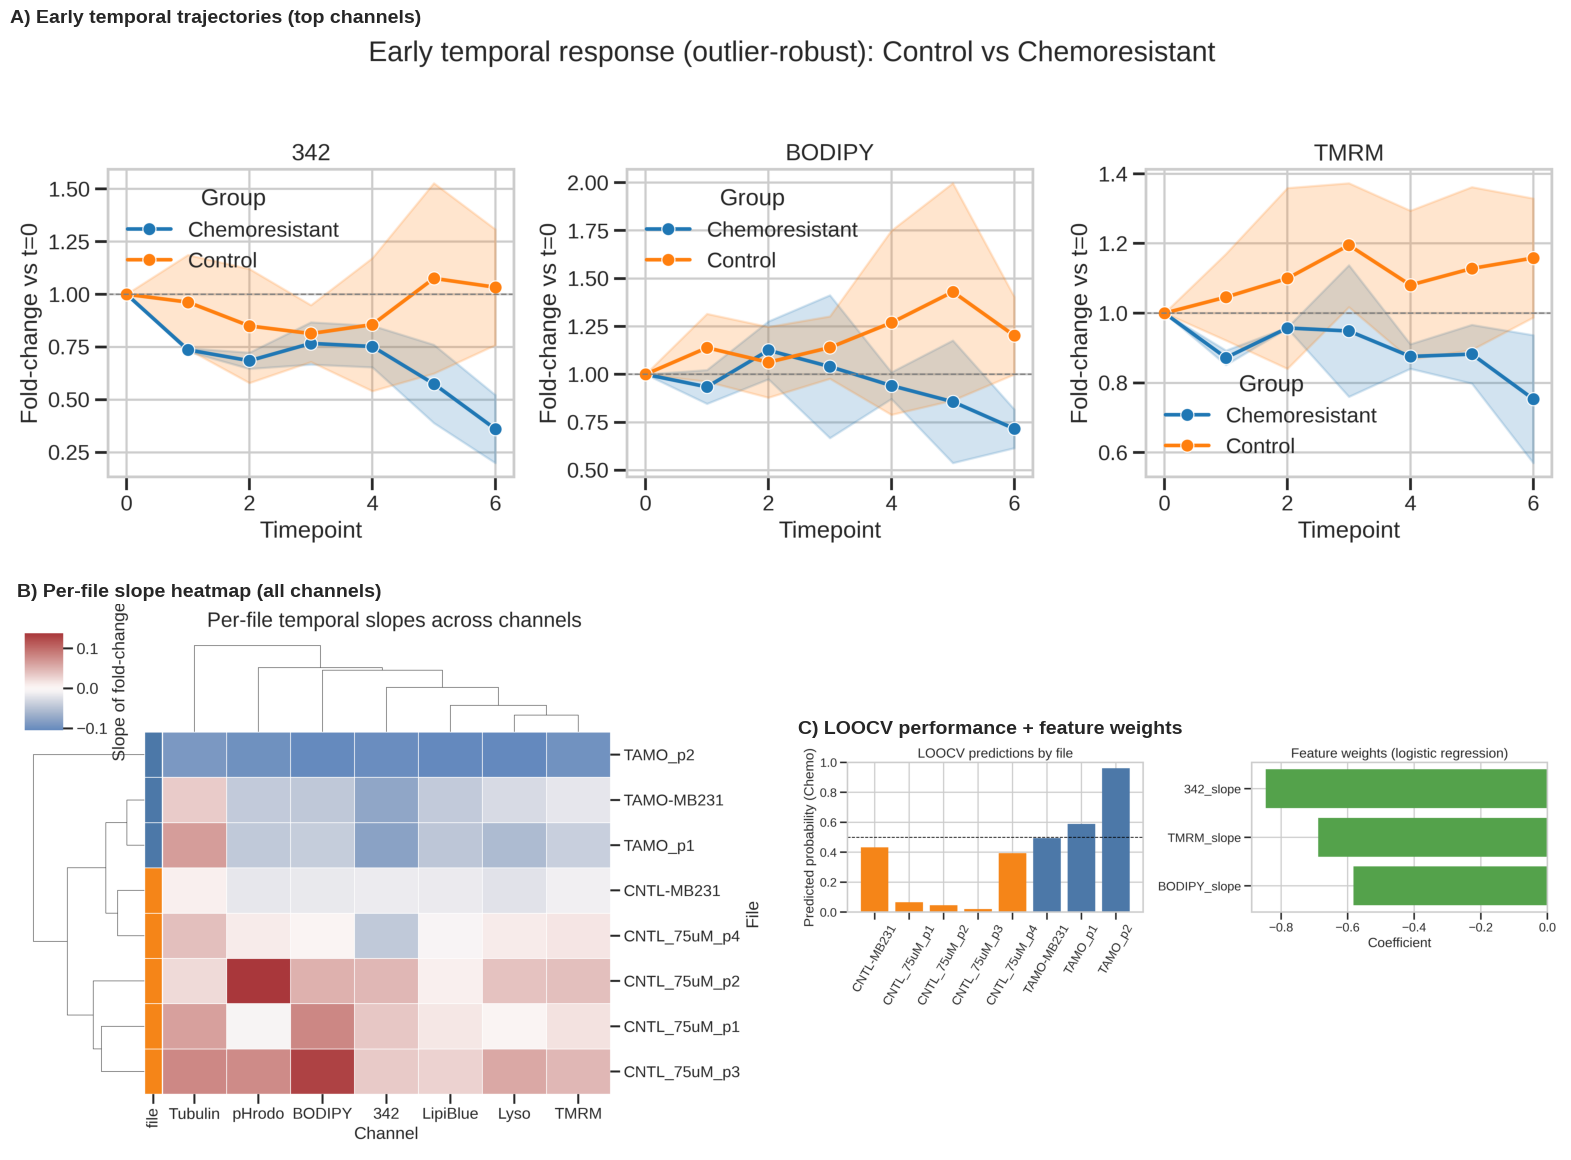

Saved:
 - results/figure4_thesis_panel_ABC.png
 - thesis/figures/figure4_thesis_panel_ABC.png


In [13]:
import matplotlib.image as mpimg

fig1 = mpimg.imread(RESULTS_DIR / 'figure1_top3_outlier_robust.png')
fig2 = mpimg.imread(RESULTS_DIR / 'figure2_slope_heatmap.png')
fig3 = mpimg.imread(RESULTS_DIR / 'figure3_model_summary.png')

panel_fig = plt.figure(figsize=(16, 12))
gs = panel_fig.add_gridspec(2, 2, height_ratios=[1, 1])

axA = panel_fig.add_subplot(gs[0, :])
axA.imshow(fig1)
axA.axis('off')
axA.set_title('A) Early temporal trajectories (top channels)', loc='left', fontsize=14, fontweight='bold')

axB = panel_fig.add_subplot(gs[1, 0])
axB.imshow(fig2)
axB.axis('off')
axB.set_title('B) Per-file slope heatmap (all channels)', loc='left', fontsize=14, fontweight='bold')

axC = panel_fig.add_subplot(gs[1, 1])
axC.imshow(fig3)
axC.axis('off')
axC.set_title('C) LOOCV performance + feature weights', loc='left', fontsize=14, fontweight='bold')

panel_fig.tight_layout()
panel_fig.savefig(RESULTS_DIR / 'figure4_thesis_panel_ABC.png', dpi=300, bbox_inches='tight')

thesis_fig_dir = Path('/home/emartinl/chemores/thesis/figures')
thesis_fig_dir.mkdir(parents=True, exist_ok=True)
panel_fig.savefig(thesis_fig_dir / 'figure4_thesis_panel_ABC.png', dpi=300, bbox_inches='tight')

plt.show()
print('Saved:')
print(' - results/figure4_thesis_panel_ABC.png')
print(' - thesis/figures/figure4_thesis_panel_ABC.png')

## 18. One-file final report (everything summarized)

In [1]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path('/home/emartinl/chemores/results')

# load existing outputs (no recomputation)
gap = pd.read_csv(RESULTS_DIR / 'temporal_full_window_group_gap.csv')
rank = pd.read_csv(RESULTS_DIR / 'temporal_channel_ranking.csv')
cv = pd.read_csv(RESULTS_DIR / 'temporal_loocv_results.csv')
imp = pd.read_csv(RESULTS_DIR / 'temporal_feature_importance.csv')

# robust parsing for group-gap file
if 'chemo_minus_control' in gap.columns:
    gap_col = 'chemo_minus_control'
elif 'Chemo_minus_Control' in gap.columns:
    gap_col = 'Chemo_minus_Control'
else:
    numeric_cols = [c for c in gap.columns if c not in ['channel', 'group']]
    gap_col = numeric_cols[0]

if 'channel' not in gap.columns:
    gap = gap.rename(columns={gap.columns[0]: 'channel'})

gap_ranked = gap[['channel', gap_col]].copy().sort_values(gap_col)
top3_gap = gap_ranked.head(3).copy()

accuracy = float(cv['correct'].mean())
misclassified = cv.loc[~cv['correct'], 'test_file'].tolist()
best_feature = imp.sort_values('abs_coefficient', ascending=False).iloc[0]

final_metrics = pd.DataFrame([
    {'metric': 'LOOCV accuracy', 'value': f'{accuracy:.2%}'},
    {'metric': 'Best feature', 'value': best_feature['feature']},
    {'metric': 'Best feature coefficient', 'value': round(float(best_feature['coefficient']), 4)},
    {'metric': 'Misclassified file(s)', 'value': ', '.join(misclassified) if misclassified else 'None'},
    {'metric': 'Top gap channel at t=6', 'value': top3_gap.iloc[0]['channel']},
    {'metric': 'Top gap value at t=6', 'value': round(float(top3_gap.iloc[0][gap_col]), 4)},
])

# save compact final summary assets
final_metrics.to_csv(RESULTS_DIR / 'temporal_final_metrics.csv', index=False)

report_lines = [
    'Temporal Analysis - Final Executive Summary',
    '===========================================',
    '',
    f'LOOCV accuracy: {accuracy:.2%}',
    f"Best feature: {best_feature['feature']} (coef={float(best_feature['coefficient']):.4f})",
    f"Misclassified file(s): {', '.join(misclassified) if misclassified else 'None'}",
    '',
    'Top channels by chemo-control gap at t=6 (more negative = stronger chemo decay):',
]
for _, row in top3_gap.iterrows():
    report_lines.append(f"  - {row['channel']}: {float(row[gap_col]):.4f}")

report_lines += [
    '',
    'Main conclusion:',
    '  Temporal dynamics carry transferable chemoresistance signal across sessions.',
    '  Channel 342 is the most robust marker in early time window analysis.',
]

(RESULTS_DIR / 'temporal_final_report.txt').write_text('\n'.join(report_lines), encoding='utf-8')

print('Saved:')
print(' - temporal_final_metrics.csv')
print(' - temporal_final_report.txt')
print('\nPreview:')
display(final_metrics)

Saved:
 - temporal_final_metrics.csv
 - temporal_final_report.txt

Preview:


,metric,value
0,LOOCV accuracy,87.50%
1,Best feature,342_slope
2,Best feature coefficient,-0.846
3,Misclassified file(s),TAMO-MB231
4,Top gap channel at t=6,342
5,Top gap value at t=6,-0.6727
